In [4]:
!pip install datasets transformers evaluate python-Levenshtein matplotlib

In [5]:
#library imports
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import evaluate
import Levenshtein
import matplotlib.pyplot as plt
import re

In [6]:
#load the test split of HumanEval
dataset = load_dataset("openai/openai_humaneval", split="test")
#extract rows 0 till 19
dataset_20 = dataset.select(range(20))
#confrim the correctness
print(len(dataset_20))
print(dataset_20[0].keys())
print(dataset_20[0]["prompt"][:300])
print(dataset_20[0]["canonical_solution"][:300])

Found cached dataset parquet (/Users/shahrzadtorabi/.cache/huggingface/datasets/openai___parquet/openai_humaneval-817820fef792da01/0.0.0/2a3b91fbd88a2c90d1dbbb32b460cf621d31bd5b05b934492fdef7d8d6f236ec)


20
dict_keys(['task_id', 'prompt', 'canonical_solution', 'test', 'entry_point'])
from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
    """ Check if in given list of numbers, are any two numbers closer to each other than
    given threshold.
    >>> has_close_elements([1.0, 2.0, 3.0], 0.5)
    False
    >>> has_close_elements([1.0, 
    for idx, elem in enumerate(numbers):
        for idx2, elem2 in enumerate(numbers):
            if idx != idx2:
                distance = abs(elem - elem2)
                if distance < threshold:
                    return True

    return False



In [47]:
#verify by printing the first 3 examples
for i in range(3):
    print("\nExample", i)
    print("Task ID:", dataset_20[i]["task_id"])
    print("Prompt:\n", dataset_20[i]["prompt"][:250])
    print("Canonical solution:\n", dataset_20[i]["canonical_solution"][:250])


Example 0
Task ID: HumanEval/0
Prompt:
 from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
    """ Check if in given list of numbers, are any two numbers closer to each other than
    given threshold.
    >>> has_close_elements([1.0, 2.0, 3.0]
Canonical solution:
     for idx, elem in enumerate(numbers):
        for idx2, elem2 in enumerate(numbers):
            if idx != idx2:
                distance = abs(elem - elem2)
                if distance < threshold:
                    return True

    return Fals

Example 1
Task ID: HumanEval/1
Prompt:
 from typing import List


def separate_paren_groups(paren_string: str) -> List[str]:
    """ Input to this function is a string containing multiple groups of nested parentheses. Your goal is to
    separate those group into separate strings and retur
Canonical solution:
     result = []
    current_string = []
    current_depth = 0

    for c in paren_string:
        if c == '(':
            

In [25]:
import re

# Python keywords should not be renamed during obfuscation
python_keywords = {
    "False","None","True","and","as","assert","async","await","break","class",
    "continue","def","del","elif","else","except","finally","for","from","global",
    "if","import","in","is","lambda","nonlocal","not","or","pass","raise","return",
    "try","while","with","yield"
}

# Pattern for Python identifiers
identifier_pattern = re.compile(r"\b[a-zA-Z_][a-zA-Z0-9_]*\b")


# Renames identifiers while keeping keywords and short names
def low_obfuscation(code: str):
    if code is None:
        return ""
# maps original_name to obfuscated_name
    mapping = {}

    def repl(match):
        token = match.group(0)

        if token in python_keywords:
            return token

        # Skip very short names (safer for Python syntax)
        if len(token) <= 2:
            return token


        # Assign a new generic name if not seen before
        if token not in mapping:
            mapping[token] = "v" + str(len(mapping))

        return mapping[token]

    # Apply replacement to all identifiers
    return identifier_pattern.sub(repl, code)

# Remove Python comments
def strip_comments(code: str):
    if code is None:
        return ""
    lines = str(code).splitlines()
    out = []
    for line in lines:
        if "#" in line:
            line = line.split("#")[0]
        out.append(line.rstrip())
    return "\n".join(out)

# Pattern for any string literal (single or double quotes)
string_pattern = re.compile(r"(\"[^\"]*\"|'[^']*')")

# Replaces all strings with "STR"
def mask_strings(code: str):
    if code is None:
        return ""
    return string_pattern.sub('"STR"', code)

# Applies all steps: rename identifiers, remove comments,mask strings, and merge excessive empty lines
def high_obfuscation(code: str):
    if code is None:
        return ""
    s = low_obfuscation(code)
    s = strip_comments(s)
    s = mask_strings(s)
    s = re.sub(r"\n\s*\n\s*\n+", "\n\n", s)
    return s



In [26]:
#prompt from first 20 sample
sample = dataset_20[0]["prompt"]

print("Type of sample:", type(sample))
#irst 200 characters of the original prompt
print("\nOriginal:\n", sample[:200])
print("\nLow:\n", low_obfuscation(sample)[:200])
print("\nHigh:\n", high_obfuscation(sample)[:200])


Type of sample: <class 'str'>

Original:
 from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
    """ Check if in given list of numbers, are any two numbers closer to each other than
    given thr

Low:
 from v0 import v1


def v2(v3: v1[v4], v5: v4) -> v6:
    """ v7 if in v8 v9 of v3, v10 v11 v12 v3 v13 to v14 v15 v16
    v8 v5.
    >>> v2([1.0, 2.0, 3.0], 0.5)
    False
    >>> v2([1.0, 2.8, 3.0, 4

High:
 from v0 import v1

def v2(v3: v1[v4], v5: v4) -> v6:
    "STR""STR""STR"


In [21]:
!pip install torch torchvision torchaudio


  Obtaining dependency information for torch from https://files.pythonhosted.org/packages/1e/ce/7d251155a783fb2c1bb6837b2b7023c622a2070a0a72726ca1df47e7ea34/torch-2.9.1-cp311-none-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for torchvision from https://files.pythonhosted.org/packages/e7/69/30f5f03752aa1a7c23931d2519b31e557f3f10af5089d787cddf3b903ecf/torchvision-0.24.1-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for torchaudio from https://files.pythonhosted.org/packages/3f/6b/34e489fcb4adc4b571a166f2670cc7f156cbe3337867a892fade0a1a5224/torchaudio-2.9.1-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for typing-extensions>=4.10.0 from https://files.pythonhosted.org/packages/18/67/36e9267722cc04a6b9f15c7f3441c2363321a3ea07da7ae0c0707beb2a9c/typing_extensions-4.15.0-py3-none-any.whl.metadata
  Obtaining dependency information for sympy>=1.13.3 from https://files.pythonhosted.org/packages/a2/09/77d55d46fd

In [27]:
#Loading CodeT5-small
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "Salesforce/codet5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)


In [28]:
#helper function to generate completions 
def generate_completion(prompt: str):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    ids = model.generate(
        **inputs,
        max_new_tokens=128,
        num_beams=4,
        early_stopping=True
    )
    return tokenizer.decode(ids[0], skip_special_tokens=True)


In [29]:
#function to give a prompt to CodeT5-small and get the model’s predicted code
def generate_completion(prompt: str):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    ids = model.generate(
        **inputs,
        max_new_tokens=128,
        num_beams=4,
        early_stopping=True
    )
    return tokenizer.decode(ids[0], skip_special_tokens=True)


In [30]:
#testing the model
print(generate_completion(dataset_20[0]["prompt"])[:300])


has_close_elements([1.0, 2.8, 3.0,0.5)
   0.5)
   0.5)
   0.5)
   0.5)
   0.5)
   


In [31]:
#generate all completions
results = []

for i, item in enumerate(dataset_20):
    base = item["prompt"]
    ref = item["canonical_solution"]

    prompts = {
        "original": base,
        "low": low_obfuscation(base),
        "high": high_obfuscation(base),
    }

    for level, p in prompts.items():
        comp = generate_completion(p)
        results.append({
            "i": i,
            "level": level,
            "prompt": p,
            "base": base,
            "comp": comp,
            "ref": ref,
        })

print("Total completions:", len(results))
  

Total completions: 60


In [41]:
import Levenshtein
import matplotlib.pyplot as plt


#Compute length of the longest common subsequence between two token lists
def lcs_length(a_tokens, b_tokens):

    m = len(a_tokens)
    n = len(b_tokens)

    # dp[i][j] = LCS length for prefixes a[:i], b[:j]
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m):
        for j in range(n):
            if a_tokens[i] == b_tokens[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i][j + 1], dp[i + 1][j])

    return dp[m][n]


# Compute the Longest Common Subsequence (LCS) length between two strings
def lcs_char(a, b):
    m, n = len(a), len(b)
    # Create a DP table of size (m+1) x (n+1)
    # dp[i][j] stores the LCS length for a[:i] and b[:j]
    dp = [[0]*(n+1) for _ in range(m+1)]
    
    # Fill the DP table
    for i in range(m):
        for j in range(n):
            if a[i] == b[j]:
                # Characters match, extend the LCS
                dp[i+1][j+1] = dp[i][j] + 1
            else:
                dp[i+1][j+1] = max(dp[i][j+1], dp[i+1][j])
    # full LCS length
    return dp[m][n]

#character-level ROUGE-L style F1 utility score
def utility(pred, ref):
    a = pred
    b = ref
    # If either is empty, utility is zero
    if not a or not b:
        return 0.0

    lcs = lcs_char(a, b)
    # Precision and recall based on character overlap
    precision = lcs / len(a)
    recall = lcs / len(b)

    if precision + recall == 0:
        return 0.0

    #F1 score
    return 2 * precision * recall / (precision + recall)


# Return a score between 0 and 1 Higher means more different from the original

def privacy(obfuscated_prompt, base_prompt):

    d = Levenshtein.distance(obfuscated_prompt, base_prompt)
    m = max(len(obfuscated_prompt), len(base_prompt))

    if m == 0:
        return 0.0

    return d / m


#privacy and utility for all 60 results
for r in results:
    r["u"] = utility(r["comp"], r["ref"])
    r["p"] = privacy(r["prompt"], r["base"])

print("Scores computed for", len(results), "items.")





Scores computed for 60 items.


In [42]:
#Inspect first few points
for level in ["original", "low", "high"]:
    print("\nLevel:", level)
    subset = [r for r in results if r["level"] == level]
    for r in subset[:3]:
        print(
            "p =", round(r["p"], 3),
            "u =", round(r["u"], 3)
        )



Level: original
p = 0.0 u = 0.228
p = 0.0 u = 0.292
p = 0.0 u = 0.168

Level: low
p = 0.477 u = 0.156
p = 0.587 u = 0.114
p = 0.616 u = 0.033

Level: high
p = 0.879 u = 0.008
p = 0.925 u = 0.005
p = 0.931 u = 0.0


In [43]:
#check average scores
def avg(xs):
    return sum(xs) / len(xs) if xs else 0.0

for level in ["original", "low", "high"]:
    vals = [r for r in results if r["level"] == level]
    avg_p = avg([r["p"] for r in vals])
    avg_u = avg([r["u"] for r in vals])
    print(
    level,
    "avg privacy:", round(avg_p, 3),
    "avg utility:", round(avg_u, 3)
    )


original avg privacy: 0.0 avg utility: 0.228
low avg privacy: 0.531 avg utility: 0.078
high avg privacy: 0.889 avg utility: 0.008


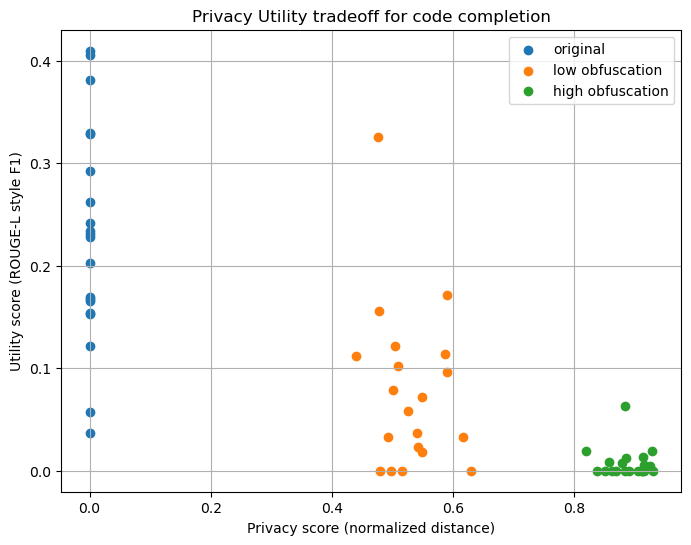

In [45]:
#Plot Privacy vs Utility


plt.figure(figsize=(8, 6))

# Each group in a different color
plt.scatter(orig_p, orig_u, label="original")
plt.scatter(low_p, low_u, label="low obfuscation")
plt.scatter(high_p, high_u, label="high obfuscation")

plt.xlabel("Privacy score (normalized distance)")
plt.ylabel("Utility score (ROUGE-L style F1)")
plt.title("Privacy Utility tradeoff for code completion")
plt.legend()
plt.grid(True)
plt.show()

# Analysis of utility privacy trade-off 

The results show a clear privacy utility tradeoff. Original prompts have a privacy score of 0.0 and an average utility of 0.228, since the model sees the full, unmodified task description. Low obfuscation increases the average privacy score to 0.531 and reduces the average utility to 0.078, which indicates that partial masking of identifiers lowers completion quality. High obfuscation reaches an average privacy score of 0.889 and drops the utility to 0.008, because most of the original information is removed. Overall, as the obfuscation strength increases, privacy improves steadily while utility declines sharply.